# 03. 퍼널 분석 (view → cart → purchase)

세션(`user_session`) 단위로 view→cart→purchase 전환율과 장바구니 이탈률을 확인한다.
`remove_from_cart` 이벤트는 01_eda에서 확인했듯 데이터에 존재하지 않으므로, 장바구니
이탈은 "cart는 있었지만 같은 세션에서 purchase로 이어지지 않은 비율"로 우회 측정한다.

월별 추이와 7개월 전체 합산을 모두 본다.

**메모리 전략**: 02_cohort_retention과 같은 원리로, 달마다 `user_session, event_type`
2개 컬럼만 읽어 그 달의 "cart 세션 집합", "purchase 세션 집합"만 뽑고 원본은 버린다.
cart→purchase 전환율은 단순히 두 집합의 개수를 나누지 않고, **교집합**(cart도 있고
purchase도 있는 세션)을 직접 계산해 정확도를 높인다.

In [2]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import config
from src import load

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

plt.rcParams["font.family"] = "AppleGothic"  # 맥북 한글 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

## 1. 월별 퍼널 집계

7개 파일을 순서대로 스캔하며, 달마다 전체 세션 수·cart 세션 집합·purchase 세션 집합을
뽑는다.

In [3]:
month_labels = ["2019-10", "2019-11", "2019-12", "2020-01", "2020-02", "2020-03", "2020-04"]

monthly_stats = []
for label, path in zip(month_labels, config.RAW_PATHS):
    df = load.load_month(path, usecols=["user_session", "event_type"])

    total_sessions = df["user_session"].nunique()
    cart_sessions = set(df.loc[df["event_type"] == "cart", "user_session"].unique())
    purchase_sessions = set(df.loc[df["event_type"] == "purchase", "user_session"].unique())
    del df

    cart_and_purchase = len(cart_sessions & purchase_sessions)
    monthly_stats.append(
        {
            "month": label,
            "total_sessions": total_sessions,
            "cart_sessions": len(cart_sessions),
            "purchase_sessions": len(purchase_sessions),
            "cart_and_purchase": cart_and_purchase,
        }
    )
    print(
        f"{label}: 전체 {total_sessions:,} / cart {len(cart_sessions):,} / "
        f"purchase {len(purchase_sessions):,} / cart+purchase {cart_and_purchase:,}"
    )

2019-10: 전체 9,244,421 / cart 573,098 / purchase 629,560 / cart+purchase 291,861
2019-11: 전체 13,776,050 / cart 1,743,343 / purchase 773,214 / cart+purchase 648,363
2019-12: 전체 15,581,360 / cart 1,983,488 / purchase 970,005 / cart+purchase 958,022
2020-01: 전체 13,847,854 / cart 1,543,485 / purchase 690,930 / cart+purchase 679,353
2020-02: 전체 13,544,595 / cart 1,660,110 / purchase 754,013 / cart+purchase 700,091
2020-03: 전체 12,658,462 / cart 1,638,659 / purchase 849,142 / cart+purchase 837,221
2020-04: 전체 11,652,261 / cart 1,826,140 / purchase 786,004 / cart+purchase 783,210


## 2. 월별 퍼널 테이블 & 전환율

- `view→cart` 전환율 = cart 세션 ÷ 전체 세션
- `cart→purchase` 전환율 = (cart이면서 purchase) ÷ cart 세션 — 교집합 기준으로 정확히 계산
- 장바구니 이탈률 = 1 − cart→purchase 전환율
- 참고: `purchase_no_cart` = 같은 세션에 cart 없이 purchase만 있는 경우 (데이터 특성 확인용)

In [4]:
monthly_funnel = pd.DataFrame(monthly_stats).set_index("month")

monthly_funnel["purchase_no_cart"] = monthly_funnel["purchase_sessions"] - monthly_funnel["cart_and_purchase"]
monthly_funnel["view_to_cart_rate"] = monthly_funnel["cart_sessions"] / monthly_funnel["total_sessions"]
monthly_funnel["cart_to_purchase_rate"] = monthly_funnel["cart_and_purchase"] / monthly_funnel["cart_sessions"]
monthly_funnel["cart_abandonment_rate"] = 1 - monthly_funnel["cart_to_purchase_rate"]

monthly_funnel

,total_sessions,cart_sessions,purchase_sessions,cart_and_purchase,purchase_no_cart,view_to_cart_rate,cart_to_purchase_rate,cart_abandonment_rate
month,,,,,,,,
2019-10,9244421,573098,629560,291861,337699,0.061994,0.509269,0.490731
2019-11,13776050,1743343,773214,648363,124851,0.126549,0.371908,0.628092
2019-12,15581360,1983488,970005,958022,11983,0.127299,0.482999,0.517001
2020-01,13847854,1543485,690930,679353,11577,0.111460,0.440142,0.559858
2020-02,13544595,1660110,754013,700091,53922,0.122566,0.421714,0.578286
2020-03,12658462,1638659,849142,837221,11921,0.129452,0.510918,0.489082
2020-04,11652261,1826140,786004,783210,2794,0.156720,0.428888,0.571112


## 3. 월별 전환율 추이 시각화

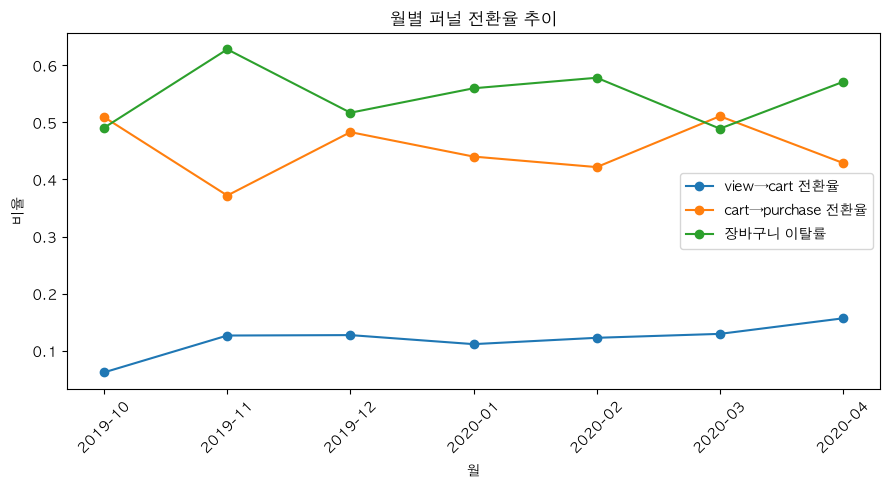

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(monthly_funnel.index, monthly_funnel["view_to_cart_rate"], marker="o", label="view→cart 전환율")
ax.plot(monthly_funnel.index, monthly_funnel["cart_to_purchase_rate"], marker="o", label="cart→purchase 전환율")
ax.plot(monthly_funnel.index, monthly_funnel["cart_abandonment_rate"], marker="o", label="장바구니 이탈률")
ax.set_title("월별 퍼널 전환율 추이")
ax.set_xlabel("월")
ax.set_ylabel("비율")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "03_funnel_monthly_trend.png", dpi=150)
plt.show()

## 4. 전체 기간(7개월) 합산 퍼널

세션 ID는 월을 넘겨 이어지지 않는다고 보고(방문 세션은 보통 짧게 끝남), 월별 고유 카운트를
그대로 합산해 7개월 전체 퍼널을 구한다.

In [6]:
overall = monthly_funnel[["total_sessions", "cart_sessions", "purchase_sessions", "cart_and_purchase", "purchase_no_cart"]].sum()

overall_view_to_cart = overall["cart_sessions"] / overall["total_sessions"]
overall_cart_to_purchase = overall["cart_and_purchase"] / overall["cart_sessions"]
overall_abandonment = 1 - overall_cart_to_purchase

print(f"전체 세션 수: {overall['total_sessions']:,}")
print(f"cart 세션 수: {overall['cart_sessions']:,}")
print(f"purchase 세션 수: {overall['purchase_sessions']:,} (그중 cart 없이 구매만: {overall['purchase_no_cart']:,})")
print(f"view→cart 전환율: {overall_view_to_cart:.1%}")
print(f"cart→purchase 전환율: {overall_cart_to_purchase:.1%}")
print(f"장바구니 이탈률: {overall_abandonment:.1%}")

전체 세션 수: 90,305,003
cart 세션 수: 10,968,323
purchase 세션 수: 5,452,868 (그중 cart 없이 구매만: 554,747)
view→cart 전환율: 12.1%
cart→purchase 전환율: 44.7%
장바구니 이탈률: 55.3%


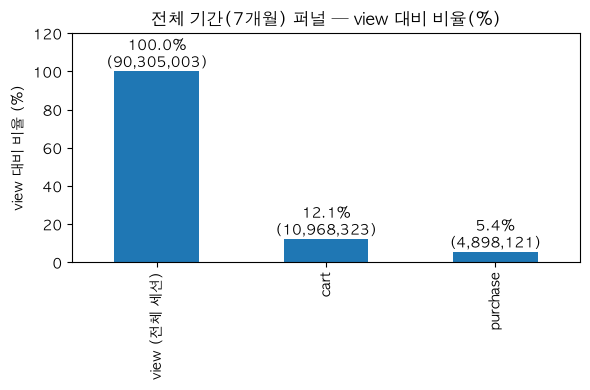

In [ ]:
funnel_stages = pd.Series(
    {
        "view (전체 세션)": overall["total_sessions"],
        "cart": overall["cart_sessions"],
        "purchase": overall["cart_and_purchase"],
    }
)
funnel_pct = funnel_stages / funnel_stages.iloc[0] * 100  # view 대비 비율(%)

fig, ax = plt.subplots(figsize=(6, 4))
funnel_pct.plot(kind="bar", ax=ax)
ax.set_title("전체 기간(7개월) 퍼널 — view 대비 비율(%)")
ax.set_ylabel("view 대비 비율 (%)")
ax.set_ylim(0, funnel_pct.max() * 1.2)
for i, (pct, count) in enumerate(zip(funnel_pct, funnel_stages)):
    ax.text(i, pct, f"{pct:.1f}%\n({count:,})", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "03_funnel_overall.png", dpi=150)
plt.show()